# Convolutional Neural Network Cats vs. Dogs Classifier

Goal:
- Use the Oxford-IIIT Pet dataset
- Convert breed labels into a binary task: cat vs dog
- Train a CNN
- Inspect learning curves
- Experiment with model architectures and multi-class classifications

In [ ]:
from google.colab import ai
response = ai.generate_text("Tell me what AI you are and can you help me with coding problems?")
print(response)

Hello!

1.  **What AI am I?**
    I am a large language model, trained by Google. I don't have a personal name or consciousness. My purpose is to assist users with information, generate text, answer questions, and generally be helpful based on the vast amount of text data I've been trained on.

2.  **Can I help you with coding problems?**
    **Absolutely, yes!** I can help you with a wide range of coding-related tasks, including:

    *   **Writing code snippets:** From simple functions to more complex algorithms.
    *   **Debugging:** Helping you identify errors in your code and suggest fixes.
    *   **Explaining concepts:** Breaking down programming paradigms, data structures, algorithms, or specific syntax.
    *   **Optimizing code:** Suggesting ways to make your code more efficient or readable.
    *   **Learning new languages/frameworks:** Providing examples, tutorials, or comparisons.
    *   **Generating boilerplate:** Setting up basic project structures or common patterns.


In [ ]:
import copy
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torch.nn.functional as F

import torchvision
from torchvision import transforms, models
from torchvision.datasets import OxfordIIITPet

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

In [ ]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### 1) Dataset: Oxford-IIIT Pet

To get into image classification, lets start easy with a cat vs. dog classifier.
We use a curated dataset from Oxford for this.
The first step is loading the data.

In [ ]:
DATA_ROOT = "./data"
ds = OxfordIIITPet(root=DATA_ROOT, split="trainval", target_types="category", download=True)
ds_test = OxfordIIITPet(root=DATA_ROOT, split="test", target_types="category", download=True)

rng = np.random.default_rng(SEED)
idx = np.arange(len(ds))
rng.shuffle(idx)

n_train = int(0.8 * len(ds))
train_idx = idx[:n_train]
val_idx = idx[n_train:]

ds_train = Subset(ds, train_idx.tolist())
ds_val = Subset(ds, val_idx.tolist())

print("Total samples training set:", len(ds_train))
print("Total samples validation set:", len(ds_val))
print("Total samples test set:", len(ds_test))

100%|██████████| 792M/792M [00:30<00:00, 26.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.0MB/s]


Total samples training set: 2944
Total samples validation set: 736
Total samples test set: 3669


In [ ]:
# Breed names in torchvision Oxford-IIIT Pet (37 classes)
breeds = ds.classes
print("Number of breed classes:", len(breeds))

dog_breeds = ['American Bulldog','American Pit Bull Terrier','Basset Hound', 'Beagle','Boxer','Chihuahua','English Cocker Spaniel',
 'English Setter','German Shorthaired','Great Pyrenees','Havanese','Japanese Chin','Keeshond','Leonberger','Miniature Pinscher','Newfoundland','Pomeranian','Pug',
 'Saint Bernard','Samoyed','Scottish Terrier','Shiba Inu','Staffordshire Bull Terrier','Wheaten Terrier','Yorkshire Terrier']
cat_breeds = ['Abyssinian','Bengal','Birman','Bombay','British Shorthair','Egyptian Mau','Maine Coon','Persian','Ragdoll','Russian Blue','Siamese','Sphynx']

print("Cat breeds:", len(cat_breeds))
print("Dog breeds:", len(dog_breeds))

Number of breed classes: 37
Cat breeds: 12
Dog breeds: 25


In [ ]:
def breed_to_catdog(breed_idx):
    breed_idx = int(breed_idx)
    if breed_idx >= len(breeds):
        breed_idx -= 1
    breed_name = breeds[breed_idx]
    if breed_name in cat_breeds:
        return 0
    if breed_name in dog_breeds:
        return 1

To see what we're working with, we first can print some sample images.

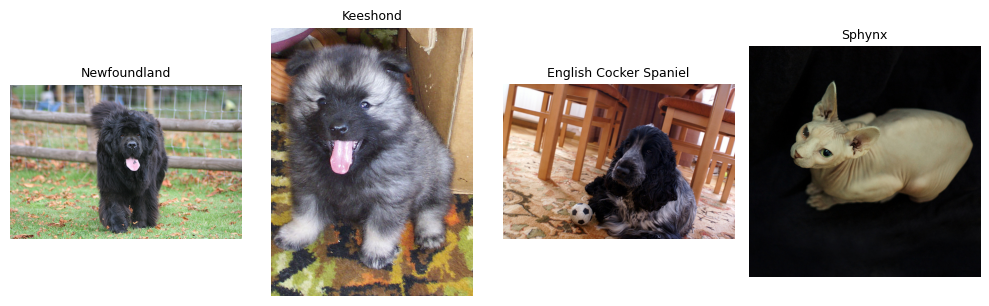

In [ ]:
n_show = 4
idxs = np.random.choice(len(ds), size=n_show, replace=False)

plt.figure(figsize=(10, 6))
for i, idx in enumerate(idxs):
    img, breed_idx = ds[idx]
    breed_idx = int(breed_idx)
    breed_name = breeds[breed_idx]

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(breed_name, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

### 2) Normalization

Input for the model needs to always have the same size. Therefore, we use normalization.


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

### 3) Dataloader

To not load all data at once, we wrap our data with a dataloader that just loads instances once they are needed.

In [ ]:
def collate_catdog(batch):
    xs = torch.stack([tfm(x[0]) for x in batch])
    ys = torch.tensor([breed_to_catdog(x[1]) for x in batch], dtype=torch.long)
    return xs, ys

In [ ]:
train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, collate_fn=collate_catdog)
val_loader   = DataLoader(ds_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_catdog)
test_loader  = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, collate_fn=collate_catdog)

Lets have a look at the normalized images and their labels.

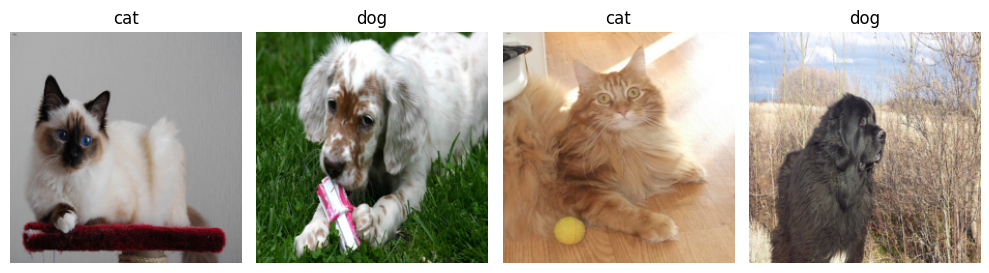

In [ ]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (img_tensor * std + mean).clamp(0, 1)

images, labels = next(iter(train_loader))
class_names = ["cat", "dog"]

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(2, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(class_names[int(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

### 4) CNN definition

Lets build our own CNN with 3 convolutional layers consisting of I) convolution, II) activation function. and III) pooling.
On top of the convolutional layers we add two dense layers for the classification task.


In [ ]:
class CNN(nn.Module):
    def __init__(self, dropout=0.2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [ ]:
model = CNN(dropout=0.3).to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=64, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

### 5) Training loop

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None, device="cuda"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    running_correct = 0
    n_samples = 0

    all_preds = []
    all_targets = []

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = model(xb)
            loss = criterion(logits, yb)
            preds = torch.argmax(logits, dim=1)

            if is_train:
                loss.backward()
                optimizer.step()

        batch_size = xb.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (preds == yb).sum().item()
        n_samples += batch_size

        all_preds.append(preds.detach().cpu())
        all_targets.append(yb.detach().cpu())

    epoch_loss = running_loss / n_samples
    epoch_acc = running_correct / n_samples
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()

    return epoch_loss, epoch_acc, all_preds, all_targets

In [ ]:
history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

num_epochs = 5

for epoch in range(1, num_epochs + 1):
      train_loss, train_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer=optimizer, device=device)
      val_loss, val_acc, _, _ = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

      history["train_loss"].append(train_loss)
      history["train_acc"].append(train_acc)
      history["val_loss"].append(val_loss)
      history["val_acc"].append(val_acc)

      print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

Epoch 01/5 | train_loss=0.6461, train_acc=0.6688 | val_loss=0.6097, val_acc=0.6698
Epoch 02/5 | train_loss=0.5744, train_acc=0.6957 | val_loss=0.6241, val_acc=0.6698
Epoch 03/5 | train_loss=0.5323, train_acc=0.7313 | val_loss=0.5528, val_acc=0.6957
Epoch 04/5 | train_loss=0.4508, train_acc=0.7911 | val_loss=0.5684, val_acc=0.7255
Epoch 05/5 | train_loss=0.3575, train_acc=0.8410 | val_loss=0.6484, val_acc=0.7188


### 6) Plot training curves

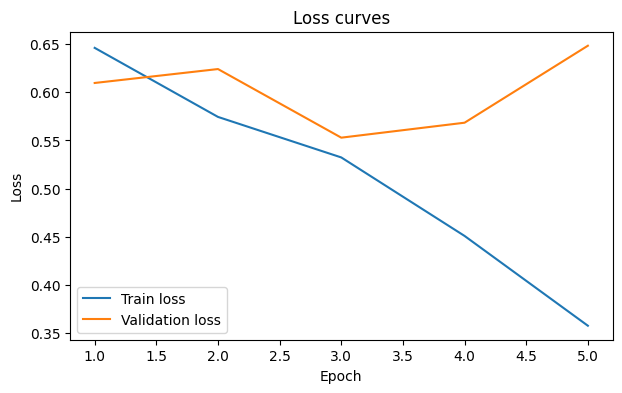

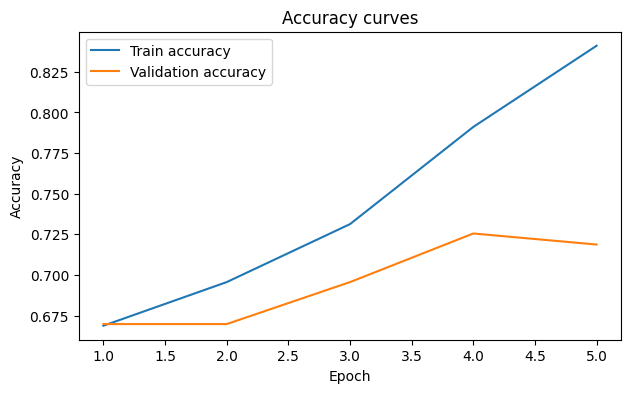

In [ ]:
epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_loss"], label="Train loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history["train_acc"], label="Train accuracy")
plt.plot(epochs, history["val_acc"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.show()

### 7) Final evaluation on test set

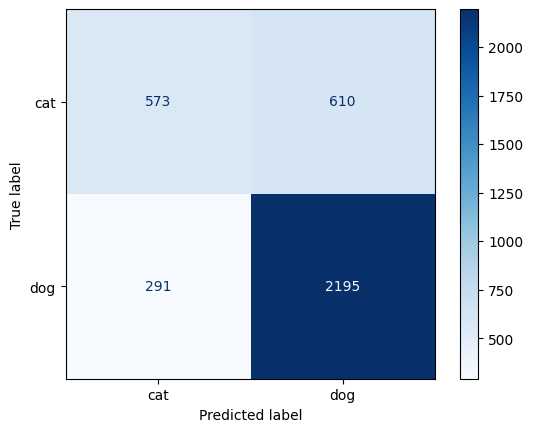

Test loss: 0.5901
Test accuracy: 0.7544

              precision    recall  f1-score   support

         cat       0.66      0.48      0.56      1183
         dog       0.78      0.88      0.83      2486

    accuracy                           0.75      3669
   macro avg       0.72      0.68      0.69      3669
weighted avg       0.74      0.75      0.74      3669



In [ ]:
test_loss, test_acc, test_preds, test_targets = run_epoch(
    model, test_loader, criterion, optimizer=None, device=device
)

cm = confusion_matrix(test_targets, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap = 'Blues')
plt.show()

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print()
print(classification_report(test_targets, test_preds, target_names=class_names))


### 8) Visualize predictions


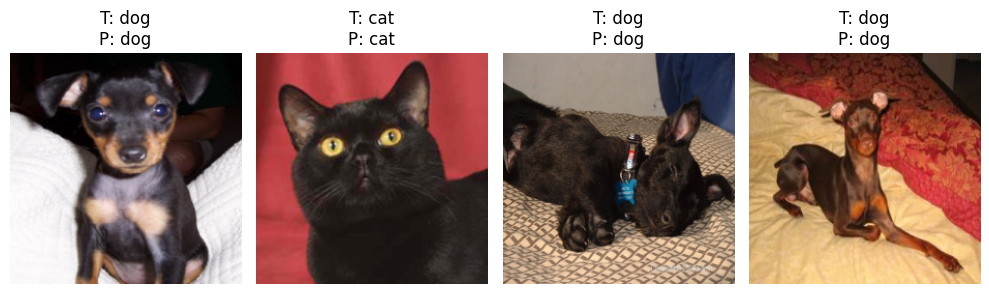

In [ ]:
def predict_batch(model, loader, class_names, device="cuda", n_show=4):
    model.eval()
    xb, yb = next(iter(loader))
    xb = xb.to(device)

    with torch.no_grad():
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu()

    plt.figure(figsize=(10, 6))
    for i in range(min(n_show, len(xb))):
        plt.subplot(2, 4, i + 1)
        img = denormalize(xb[i].cpu()).permute(1, 2, 0).numpy()
        true_label = class_names[yb[i].item()]
        pred_label = class_names[preds[i].item()]
        plt.imshow(img)
        plt.title(f"T: {true_label}\nP: {pred_label}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

predict_batch(model, val_loader, class_names, device=device)

Exercise 1: Change number of convolutional layers and filter sizes. Please be aware that the dimensionalities need to match!

Exercise 2: Make this a multi class clasiification of the different cat and dog breeds. For this you need to change the labels, the output dimension and the evaluation. (You may use the AI assistant.)

____________________________________________________________________

### (Optional) Transfer Learning

In [ ]:
class PretrainedResNet(nn.Module):
    def __init__(self, pretrained=True, dropout=0.0, num_classes=2):
        super().__init__()

        backbone = "resnet18"
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet18(weights=weights)
        in_features = self.backbone.fc.in_features

        for param in self.backbone.parameters():
            param.requires_grad = False

        self.backbone.fc = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


model2 = PretrainedResNet(
    pretrained=True,
    dropout=0.2,
    num_classes=2
).to(device)

print(model2)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 47.9MB/s]


PretrainedResNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

In [ ]:
lr = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=lr)

num_epochs = 5
history2 = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

num_epochs = 5

for epoch in range(1, num_epochs + 1):
      train_loss, train_acc, _, _ = run_epoch(model2, train_loader, criterion, optimizer=optimizer, device=device)
      val_loss, val_acc, _, _ = run_epoch(model2, val_loader, criterion, optimizer=None, device=device)

      history2["train_loss"].append(train_loss)
      history2["train_acc"].append(train_acc)
      history2["val_loss"].append(val_loss)
      history2["val_acc"].append(val_acc)

      print(
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

Epoch 01/5 | train_loss=0.2236, train_acc=0.9192 | val_loss=0.0875, val_acc=0.9810
Epoch 02/5 | train_loss=0.1167, train_acc=0.9613 | val_loss=0.0697, val_acc=0.9837
Epoch 03/5 | train_loss=0.0924, train_acc=0.9694 | val_loss=0.0517, val_acc=0.9851
Epoch 04/5 | train_loss=0.0830, train_acc=0.9715 | val_loss=0.0442, val_acc=0.9864
Epoch 05/5 | train_loss=0.0838, train_acc=0.9664 | val_loss=0.0417, val_acc=0.9878


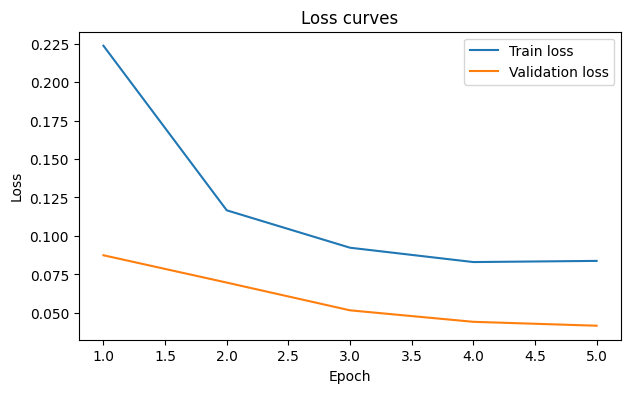

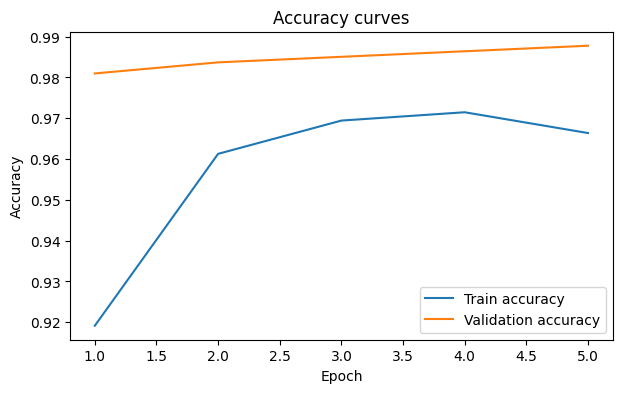

In [ ]:
epochs = np.arange(1, len(history2["train_loss"]) + 1)

plt.figure(figsize=(7, 4))
plt.plot(epochs, history2["train_loss"], label="Train loss")
plt.plot(epochs, history2["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(epochs, history2["train_acc"], label="Train accuracy")
plt.plot(epochs, history2["val_acc"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy curves")
plt.legend()
plt.show()

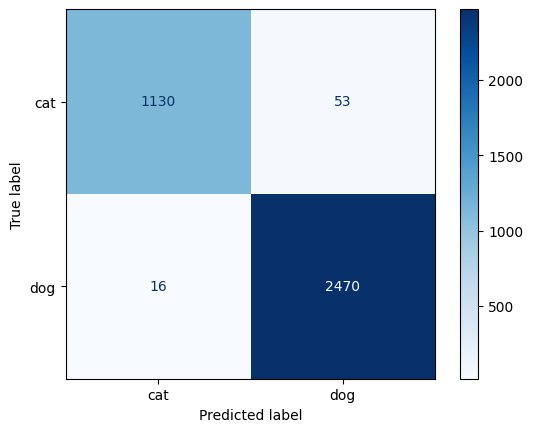

Test loss: 0.0512
Test accuracy: 0.9812

              precision    recall  f1-score   support

         cat       0.99      0.96      0.97      1183
         dog       0.98      0.99      0.99      2486

    accuracy                           0.98      3669
   macro avg       0.98      0.97      0.98      3669
weighted avg       0.98      0.98      0.98      3669



In [ ]:
test_loss, test_acc, test_preds, test_targets = run_epoch(
    model2, test_loader, criterion, optimizer=None, device=device
)

cm = confusion_matrix(test_targets, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap = 'Blues')
plt.show()

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print()
print(classification_report(test_targets, test_preds, target_names=class_names))

### (Optional) Latent Space - Feature extraction from the model layer

We extract embeddings from the layer before the final classifier (fc) and visualize them in 2D using PCA.

In [ ]:
@torch.no_grad()
def extract_features(model, loader, device="cpu", max_samples=400):
    model.eval()
    feature_extractor = nn.Sequential(*list(model.children())[:-1]).to(device)
    feature_extractor.eval()

    all_features, all_labels = [], []
    n_collected = 0

    for xb, yb in loader:
        xb = xb.to(device)
        feats = feature_extractor(xb)
        feats = F.adaptive_avg_pool2d(feats, output_size=1)

        feats = feats.flatten(1)

        all_features.append(feats.cpu())
        all_labels.append(yb.cpu())

        n_collected += xb.size(0)
        if n_collected >= max_samples:
            break

    features = torch.cat(all_features, dim=0)[:max_samples].detach().numpy()
    labels = torch.cat(all_labels, dim=0)[:max_samples].detach().numpy()
    return features, labels

features, feat_labels = extract_features(model, val_loader, device=device)

print("Feature matrix shape:", features.shape)
print("Labels shape:", feat_labels.shape)

features2, feat_labels2 = extract_features(model2.backbone, val_loader, device=device)
print("Feature matrix shape:", features.shape)
print("Labels shape:", feat_labels.shape)

Feature matrix shape: (400, 64)
Labels shape: (400,)
Feature matrix shape: (400, 64)
Labels shape: (400,)


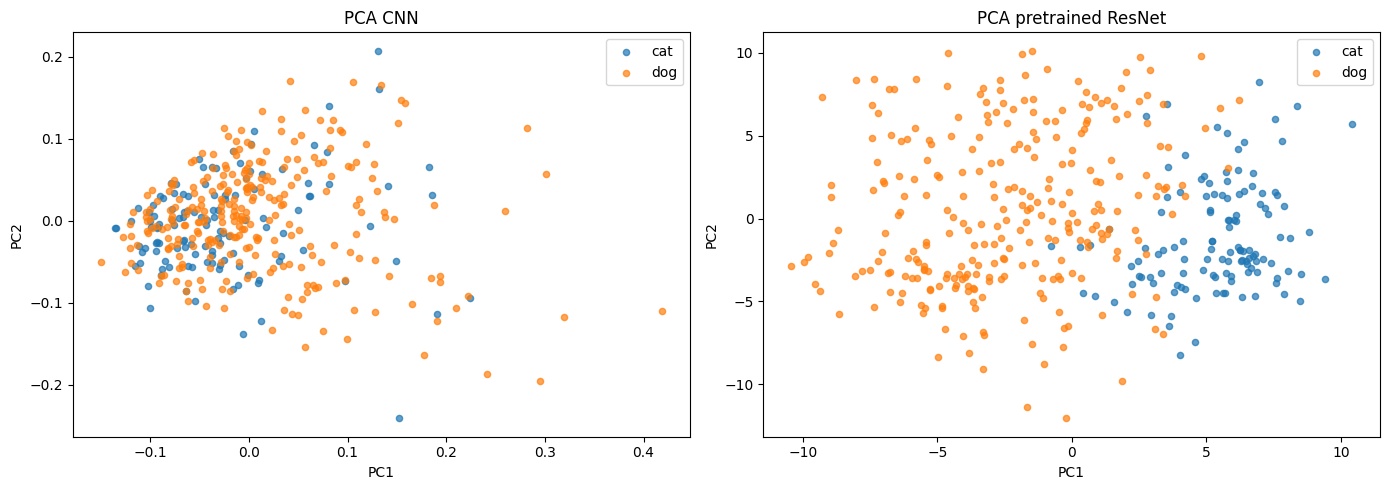

Explained variance ratio CNN: 0.738
Explained variance ratio pretrained ResNet: 0.134


In [ ]:
pca = PCA(n_components=2, random_state=42)
pca2 = PCA(n_components=2, random_state=42)

a_2d = pca.fit_transform(features)
b_2d = pca2.fit_transform(features2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False, sharey=False)

for class_idx, class_name in enumerate(class_names):
    mask_a = feat_labels == class_idx
    axes[0].scatter(a_2d[mask_a, 0], a_2d[mask_a, 1], label=class_name, alpha=0.7, s=20)

axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("PCA CNN")
axes[0].legend()

for class_idx, class_name in enumerate(class_names):
    mask_b = feat_labels2 == class_idx
    axes[1].scatter(b_2d[mask_b, 0], b_2d[mask_b, 1], label=class_name, alpha=0.7, s=20)

axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("PCA pretrained ResNet")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Explained variance ratio CNN:", pca.explained_variance_ratio_.sum().round(3))
print("Explained variance ratio pretrained ResNet:", pca2.explained_variance_ratio_.sum().round(3))